In [5]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "data.csv"

df = pd.read_csv(CSV_PATH, usecols=["user_id", "order_id", "created_at", "status"])
df["created_at"] = pd.to_datetime(df["created_at"], utc=True, errors="coerce")
df = df.dropna(subset=["user_id", "order_id", "created_at"]).copy()

def build_user_datasets(source_df, segment_name, only_complete=False):
    d = source_df.copy()
    if only_complete:
        d = d[d["status"].astype(str).str.strip().str.lower() == "complete"].copy()

    # 1 заказ = 1 запись (в заказе может быть несколько товаров)
    orders = (
        d.sort_values(["user_id", "order_id", "created_at"])
         .drop_duplicates(subset=["order_id"], keep="first")
         .copy()
    )

    # A) Датасет для гистограммы количества покупок
    orders_per_user = (
        orders.groupby("user_id", as_index=False)["order_id"]
              .nunique()
              .rename(columns={"order_id": "orders_count"})
    )
    orders_per_user["segment"] = segment_name

    # B) Датасет для гистограммы интервалов между покупками (внутри user_id)
    u = orders.sort_values(["user_id", "created_at"]).copy()
    u["prev_created_at"] = u.groupby("user_id")["created_at"].shift(1)
    u["days_between"] = (u["created_at"] - u["prev_created_at"]).dt.total_seconds() / 86400

    intervals = u.loc[u["days_between"].notna() & (u["days_between"] >= 0), ["user_id", "days_between"]].copy()
    intervals["segment"] = segment_name

    single_purchase_users = int((orders_per_user["orders_count"] == 1).sum())
    return orders_per_user, intervals, single_purchase_users


# all orders
opc_all, int_all, single_all = build_user_datasets(df, "all_orders", only_complete=False)

# only complete
opc_comp, int_comp, single_comp = build_user_datasets(df, "complete_orders", only_complete=True)

# сохраняем CSV
opc_all.to_csv("orders_per_user_all.csv", index=False)
int_all.to_csv("intervals_between_purchases_all.csv", index=False)

opc_comp.to_csv("orders_per_user_complete.csv", index=False)
int_comp.to_csv("intervals_between_purchases_complete.csv", index=False)

print(f"Пользователей с 1 покупкой (all): {single_all:,}")
print(f"Пользователей с 1 покупкой (complete): {single_comp:,}")


Пользователей с 1 покупкой (all): 48,815
Пользователей с 1 покупкой (complete): 23,569


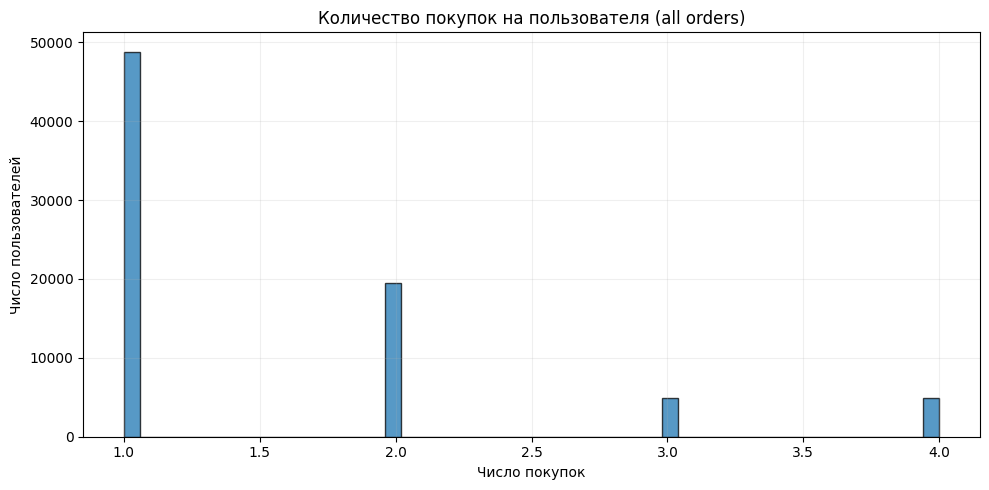

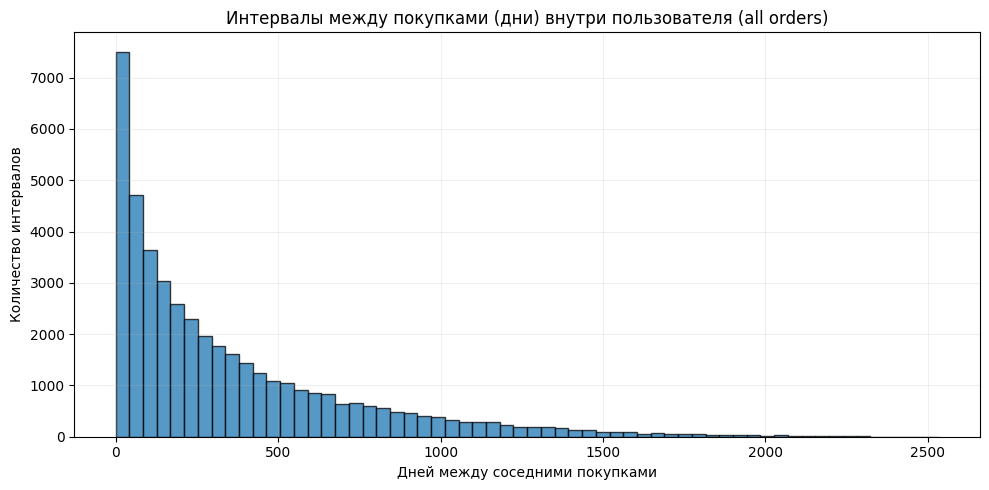

Пользователей с одной покупкой (all orders): 48,815


In [6]:
# Графики для all_orders

plt.figure(figsize=(10, 5))
plt.hist(opc_all["orders_count"], bins=50, edgecolor="black", alpha=0.75)
plt.title("Количество покупок на пользователя (all orders)")
plt.xlabel("Число покупок")
plt.ylabel("Число пользователей")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(int_all["days_between"], bins=60, edgecolor="black", alpha=0.75)
plt.title("Интервалы между покупками (дни) внутри пользователя (all orders)")
plt.xlabel("Дней между соседними покупками")
plt.ylabel("Количество интервалов")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Пользователей с одной покупкой (all orders): {single_all:,}")


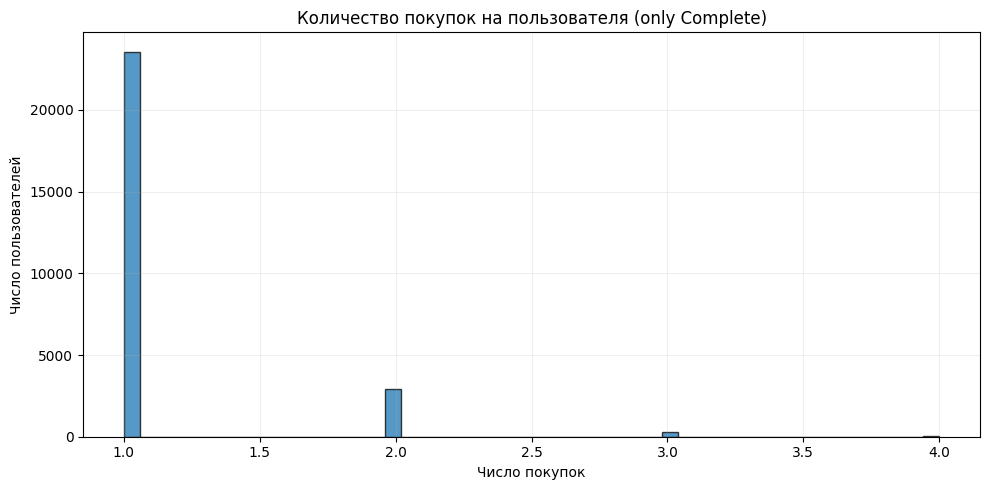

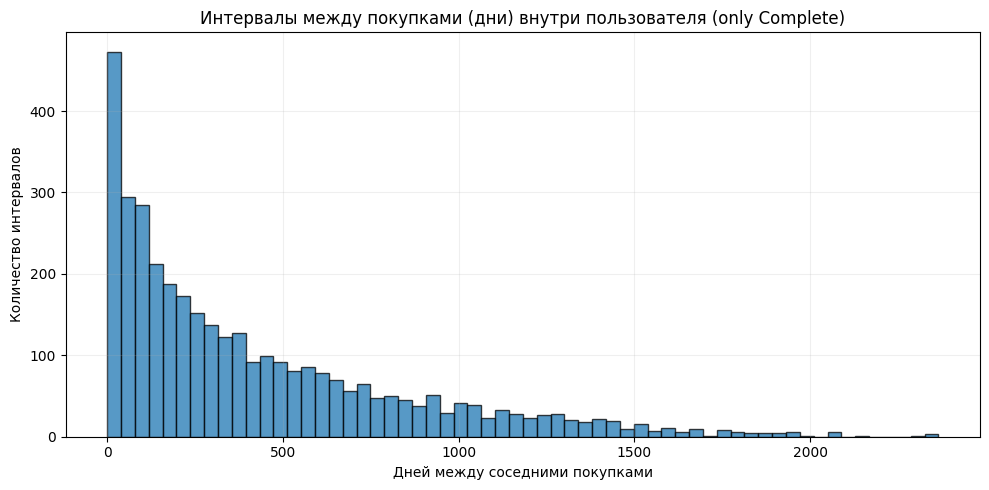

Пользователей с одной покупкой (only Complete): 23,569


In [7]:
# Графики для complete_orders

plt.figure(figsize=(10, 5))
plt.hist(opc_comp["orders_count"], bins=50, edgecolor="black", alpha=0.75)
plt.title("Количество покупок на пользователя (only Complete)")
plt.xlabel("Число покупок")
plt.ylabel("Число пользователей")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(int_comp["days_between"], bins=60, edgecolor="black", alpha=0.75)
plt.title("Интервалы между покупками (дни) внутри пользователя (only Complete)")
plt.xlabel("Дней между соседними покупками")
plt.ylabel("Количество интервалов")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Пользователей с одной покупкой (only Complete): {single_comp:,}")


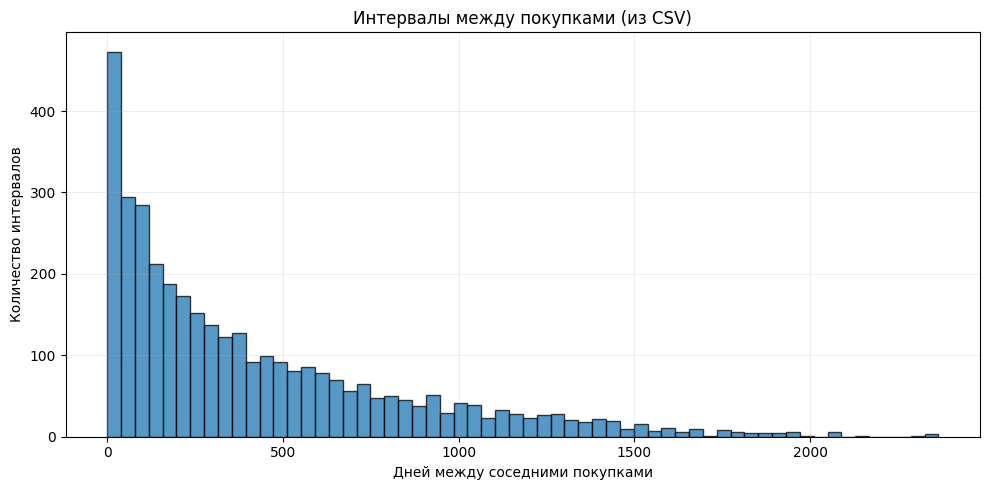

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

d = pd.read_csv("intervals_between_purchases_complete.csv")
plt.figure(figsize=(10, 5))
plt.hist(d["days_between"], bins=60, edgecolor="black", alpha=0.75)
plt.title("Интервалы между покупками (из CSV)")
plt.xlabel("Дней между соседними покупками")
plt.ylabel("Количество интервалов")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "data.csv"
CHURN_DAYS =  10

# ---------- helper ----------
def parse_dt(s):
    s = s.astype(str).str.strip().replace({
        "": np.nan, " ": np.nan, "null": np.nan, "none": np.nan, "nan": np.nan, "nat": np.nan
    })
    return pd.to_datetime(s, utc=True, errors="coerce")

# ---------- load ----------
df = pd.read_csv(CSV_PATH, usecols=["user_id", "order_id", "status", "created_at", "delivered_at"])
df["status"] = df["status"].astype(str).str.strip().str.lower()
df["created_at"] = parse_dt(df["created_at"])
df["delivered_at"] = parse_dt(df["delivered_at"])

# Базовая таблица заказов (1 order_id = 1 строка)
orders_all = (
    df.dropna(subset=["user_id", "order_id", "created_at"])
      .sort_values(["order_id", "created_at"])
      .drop_duplicates(subset=["order_id"], keep="first")
      .copy()
)

# Доставленные заказы для расчета delivery_days
orders_delivered = orders_all.dropna(subset=["delivered_at"]).copy()
orders_delivered["delivery_days"] = (orders_delivered["delivered_at"] - orders_delivered["created_at"]).dt.total_seconds() / 86400
orders_delivered = orders_delivered[(orders_delivered["delivery_days"] >= 0) & (orders_delivered["delivery_days"] <= 120)].copy()

# user-level среднее время доставки
user_delivery = orders_delivered.groupby("user_id", as_index=False).agg(
    avg_delivery_days=("delivery_days", "mean")
)

# ---------- churn ----------
last_purchase = orders_all.groupby("user_id", as_index=False)["created_at"].max().rename(columns={"created_at": "last_purchase_at"})
obs_end = orders_all["created_at"].max()
last_purchase["days_since_last"] = (obs_end - last_purchase["last_purchase_at"]).dt.days
last_purchase["churn"] = (last_purchase["days_since_last"] >= CHURN_DAYS).astype(int)

# ---------- cancel rate ----------
orders_all["is_cancel"] = (orders_all["status"] == "cancelled").astype(int)
user_cancel = orders_all.groupby("user_id", as_index=False).agg(
    cancel_rate=("is_cancel", "mean"),
    orders_count=("order_id", "nunique")
)

# ---------- merge ----------
user_metrics = (
    user_delivery
    .merge(last_purchase[["user_id", "churn"]], on="user_id", how="inner")
    .merge(user_cancel[["user_id", "cancel_rate", "orders_count"]], on="user_id", how="inner")
    .dropna(subset=["avg_delivery_days"])
    .copy()
)

if user_metrics["avg_delivery_days"].nunique() < 3:
    raise ValueError("Слишком мало вариативности delivery_days для графиков")

# ---------- bins ----------
q = min(10, int(user_metrics["avg_delivery_days"].nunique()))
user_metrics["delivery_bin"] = pd.qcut(user_metrics["avg_delivery_days"], q=q, duplicates="drop")

plot_df = user_metrics.groupby("delivery_bin", observed=True, as_index=False).agg(
    p_churn=("churn", "mean"),
    p_cancel=("cancel_rate", "mean"),
    users=("user_id", "nunique")
)

x = plot_df["delivery_bin"].astype(str)

# ---------- plot 1: churn ----------
plt.figure(figsize=(11, 5))
plt.plot(x, plot_df["p_churn"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Среднее время доставки пользователя (квантильные бины)")
plt.ylabel("P(churn)")
plt.title("Вероятность оттока от времени доставки")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ---------- plot 2: cancel ----------
plt.figure(figsize=(11, 5))
plt.plot(x, plot_df["p_cancel"], marker="o", color="tomato")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Среднее время доставки пользователя (квантильные бины)")
plt.ylabel("P(cancel)")
plt.title("Вероятность отмены заказа от времени доставки")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(plot_df)


ValueError: Слишком мало вариативности delivery_days для графиков

In [11]:
# Вместо блока с raise + qcut поставь этот код

# ---------- merge ----------
user_metrics = (
    user_delivery
    .merge(last_purchase[["user_id", "churn"]], on="user_id", how="inner")
    .merge(user_cancel[["user_id", "cancel_rate", "orders_count"]], on="user_id", how="inner")
    .dropna(subset=["avg_delivery_days"])
    .copy()
)

if user_metrics.empty:
    raise ValueError("После merge нет данных для построения графиков")

nuniq = user_metrics["avg_delivery_days"].nunique()

# ---------- устойчивое биннинг/агрегация ----------
if nuniq >= 5:
    q = min(10, int(nuniq))
    user_metrics["x_bin"] = pd.qcut(user_metrics["avg_delivery_days"], q=q, duplicates="drop").astype(str)
    plot_df = user_metrics.groupby("x_bin", as_index=False).agg(
        p_churn=("churn", "mean"),
        p_cancel=("cancel_rate", "mean"),
        users=("user_id", "nunique")
    )
    x = plot_df["x_bin"]
else:
    # Если мало уникальных значений — строим по самим значениям доставки
    user_metrics["x_val"] = user_metrics["avg_delivery_days"].round(3)
    plot_df = user_metrics.groupby("x_val", as_index=False).agg(
        p_churn=("churn", "mean"),
        p_cancel=("cancel_rate", "mean"),
        users=("user_id", "nunique")
    ).sort_values("x_val")
    x = plot_df["x_val"].astype(str)

# ---------- plot 1: churn ----------
plt.figure(figsize=(11, 5))
plt.plot(x, plot_df["p_churn"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Время доставки (бины или значения)")
plt.ylabel("P(churn)")
plt.title("Вероятность оттока от времени доставки")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ---------- plot 2: cancel ----------
plt.figure(figsize=(11, 5))
plt.plot(x, plot_df["p_cancel"], marker="o", color="tomato")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Время доставки (бины или значения)")
plt.ylabel("P(cancel)")
plt.title("Вероятность отмены заказа от времени доставки")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(plot_df)
print("Уникальных avg_delivery_days:", nuniq)


ValueError: После merge нет данных для построения графиков